In [540]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [541]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import accuracy_score

In [542]:
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [543]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [544]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [545]:
df.isna().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [546]:
df = df.drop("Id",axis=1)
X = df.drop("Species", axis=1)
y = df["Species"]

In [547]:
encoder = LabelEncoder()
y_int = encoder.fit_transform(y)
y_int

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [548]:
X_train, X_test, y_train, y_test = train_test_split(X, y_int, test_size=0.2, random_state=42, stratify=y_int)

In [549]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)
X_train_scaled

array([[-1.72156775, -0.32483982, -1.34703555, -1.32016847],
       [-1.12449223, -1.22612948,  0.41429037,  0.65186742],
       [ 1.14439475, -0.55016223,  0.58474127,  0.25746024],
       [-1.12449223,  0.12580502, -1.29021859, -1.45163753],
       [-0.40800161, -1.22612948,  0.13020555,  0.12599118],
       [ 0.54731923, -1.22612948,  0.6983752 ,  0.91480554],
       [-0.2885865 , -0.77548465,  0.24383948,  0.12599118],
       [ 0.54731923, -0.55016223,  0.75519216,  0.3889293 ],
       [ 2.21913069, -0.0995174 ,  1.32336182,  1.44068178],
       [ 2.21913069,  1.70306192,  1.66426361,  1.30921272],
       [ 2.09971558, -0.0995174 ,  1.60744665,  1.17774366],
       [ 0.18907392, -0.32483982,  0.41429037,  0.3889293 ],
       [-1.00507713, -2.35274155, -0.15387928, -0.268416  ],
       [-0.04975629, -0.77548465,  0.18702251, -0.268416  ],
       [-0.04975629, -1.00080706,  0.13020555, -0.00547788],
       [-1.36332244,  0.35112743, -1.23340162, -1.32016847],
       [-0.88566202,  1.

In [550]:
# now we will create perceptron first
# max_iter = 1000 means 1000 epochs
from sklearn.linear_model import Perceptron

per = Perceptron(max_iter=1000, random_state=42)
per.fit(X_train_scaled,y_train)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,42


In [551]:
y_pred_perc = per.predict(X_test_scaled)
print(accuracy_score(y_test,y_pred_perc))

0.8666666666666667


# ANN MODEL

In [552]:
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras import layers

In [553]:
# here are 3 diff output variables and we will use softmax and categorical cross entropy and in this we always do
# one hot encoding first on output column

from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train,num_classes = 3)
y_test_cat = to_categorical(y_test, num_classes = 3)

In [554]:
from tensorflow.keras import Sequential
model = Sequential([
    # layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(16, input_dim = 4, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3,activation="softmax")\
])

model.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])

history = model.fit(
    X_train_scaled,y_train_cat,
    # validation_data = (X_test_scaled, y_test_cat),
    epochs = 100, batch_size = 8, 
    validation_split = 0.2, 
    verbose = 1
)

Epoch 1/100


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5312 - loss: 1.0289 - val_accuracy: 0.5833 - val_loss: 0.9736
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6146 - loss: 0.9583 - val_accuracy: 0.5833 - val_loss: 0.9253
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6667 - loss: 0.9000 - val_accuracy: 0.5833 - val_loss: 0.8825
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6875 - loss: 0.8484 - val_accuracy: 0.5833 - val_loss: 0.8438
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6875 - loss: 0.7999 - val_accuracy: 0.5833 - val_loss: 0.8092
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6875 - loss: 0.7588 - val_accuracy: 0.5833 - val_loss: 0.7754
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6875 - loss: 0.7198 - val_accuracy: 0.5833 - val_loss: 0.7436
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6875 - loss: 0.6827 - val_accuracy: 0.5833 - val_loss: 0.7

In [555]:
loss, acc = model.evaluate(X_test_scaled, y_test_cat, verbose=1)
print(acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9667 - loss: 0.1118
0.9666666388511658


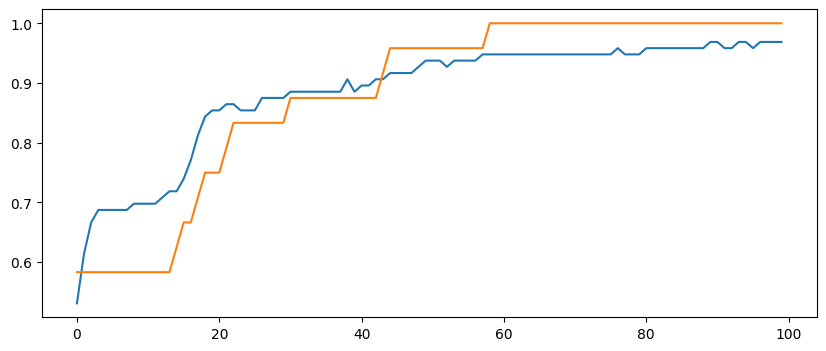

In [556]:
plt.figure(figsize=(10,4))
plt.plot(history.history["accuracy"], label = "train Acc")
plt.plot(history.history["val_accuracy"], label = "val Acc")